# C题数据处理工作台
按顺序运行单元格（Shift + Enter）。首次使用时在右上角选择 Python 内核。

本 Notebook 读取附件1—4，检查数据、生成基础长表和探索图。原始 Excel 不会被覆盖。

**口径：** 暂按区间平均功率计算十分钟电量（kW / 6），这是建模假设。小时预报保留原版本，暂不自动插值。全年实际数据仅用于分析与回放，不能当作决策时已知的未来数据。

若提示缺少包，取消下一格第一行注释后运行一次，再重启内核。

In [1]:
# %pip install pandas numpy openpyxl matplotlib ipykernel

In [2]:
%matplotlib inline
from pathlib import Path
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 若移动了文件夹，只需修改 ROOT。
ROOT = Path.cwd()
if not (ROOT / '附件').is_dir():
    ROOT = Path('/Users/mike/Desktop/国赛')
DATA = ROOT / '附件'
assert DATA.is_dir(), f'找不到附件目录：{DATA}'
pd.set_option('display.max_columns', 12)
print('数据目录：', DATA)


Matplotlib is building the font cache; this may take a moment.


数据目录： /Users/mike/Desktop/国赛/附件


## 1. 读取与预览原始表格
所有原始表保存在 raw 字典中，例如 `raw["附件2.xlsx"]["小区负载"]`。

In [3]:
raw = {f'附件{i}.xlsx': pd.read_excel(DATA / f'附件{i}.xlsx', sheet_name=None) for i in range(1, 5)}
inventory = pd.DataFrame([
    {'文件': f, '工作表': s, '行数': len(df), '列数': len(df.columns)}
    for f, sheets in raw.items() for s, df in sheets.items()
])
display(inventory)
display(raw['附件1.xlsx']['Sheet1'].head())

,文件,工作表,行数,列数
0,附件1.xlsx,Sheet1,144,4
1,附件2.xlsx,小区负载,365,145
2,附件2.xlsx,光伏发电实际功率,365,145
3,附件3.xlsx,Sheet1,1460,26
4,附件4.xlsx,Sheet1,365,145


,时间,电价,小区负载,光伏发电预测功率
0,00:10:00,0.4248,3439.8466,0.0
1,00:20:00,0.4245,3437.9792,0.0
2,00:30:00,0.4269,3444.3031,0.0
3,00:40:00,0.4272,3454.4437,0.0
4,00:50:00,0.4271,3458.8273,0.0


## 2. 通用时间解析和数值检查
严格检查时段顺序，避免按字符串排序造成错位。异常数据先报告，不删除或填补。

In [4]:
def minute_of_day(value):
    if isinstance(value, (dt.time, dt.datetime, pd.Timestamp)):
        return value.hour * 60 + value.minute
    text = str(value).strip()
    extra = 1440 if '+1' in text else 0
    parts = text.replace('+1', '').split(':')
    return int(parts[0]) * 60 + int(parts[1]) + extra

def check_slots(values):
    minutes = [minute_of_day(v) for v in values]
    assert minutes == list(range(10, 1441, 10)), '时段不是连续的0:10到24:00'
    return minutes

def numeric_block(frame):
    out = frame.apply(pd.to_numeric, errors='raise')
    assert np.isfinite(out.to_numpy(dtype=float)).all(), '发现缺失或无穷值'
    assert (out >= 0).all().all(), '发现负数，请核查原表'
    return out


## 3. 第1问：144时段基础数据
功率保留为 kW，派生电量为 kWh；净负载允许为负。此处不生成优化策略。

In [5]:
source = raw['附件1.xlsx']['Sheet1']
minutes = check_slots(source.iloc[:, 0])
values = numeric_block(source.iloc[:, 1:])
q1_day = pd.DataFrame({'slot_id': range(1, 145)})
q1_day['start_time'] = [f'{(m-10)//60:02d}:{(m-10)%60:02d}' for m in minutes]
q1_day['end_time'] = [f'{m//60:02d}:{m%60:02d}' for m in minutes]
q1_day[['price_yuan_per_kwh', 'load_kw', 'pv_forecast_kw']] = values.to_numpy()
q1_day['load_kwh'] = q1_day.load_kw / 6
q1_day['pv_forecast_kwh'] = q1_day.pv_forecast_kw / 6
q1_day['net_load_forecast_kwh'] = q1_day.load_kwh - q1_day.pv_forecast_kwh
fixed_price = q1_day[['slot_id', 'start_time', 'end_time', 'price_yuan_per_kwh']].copy()
display(q1_day.head())

,slot_id,start_time,end_time,price_yuan_per_kwh,load_kw,pv_forecast_kw,load_kwh,pv_forecast_kwh,net_load_forecast_kwh
0,1,00:00,00:10,0.4248,3439.8466,0.0,573.307767,0.0,573.307767
1,2,00:10,00:20,0.4245,3437.9792,0.0,572.996533,0.0,572.996533
2,3,00:20,00:30,0.4269,3444.3031,0.0,574.050517,0.0,574.050517
3,4,00:30,00:40,0.4272,3454.4437,0.0,575.740617,0.0,575.740617
4,5,00:40,00:50,0.4271,3458.8273,0.0,576.471217,0.0,576.471217


## 4. 全年实际数据转长表并对齐
按完整时间一对一合并。末段结束于2026年1月1日，但仍属于2025年12月31日。

In [6]:
def annual_long(frame, value_name):
    minutes = check_slots(frame.columns[1:])
    dates = pd.to_datetime(frame.iloc[:, 0], errors='raise').dt.normalize()
    assert len(dates) == 365 and dates.is_unique
    assert list(dates) == list(pd.date_range('2025-01-01', '2025-12-31'))
    values = numeric_block(frame.iloc[:, 1:])
    result = pd.DataFrame({
        'date': np.repeat(dates.to_numpy(), 144),
        'slot_id': np.tile(np.arange(1, 145), 365),
        value_name: values.to_numpy().reshape(-1),
    })
    result['interval_end'] = result.date + pd.to_timedelta(np.tile(minutes, 365), unit='m')
    result['interval_start'] = result.interval_end - pd.Timedelta(minutes=10)
    assert result.interval_start.is_unique
    return result

load = annual_long(raw['附件2.xlsx']['小区负载'], 'load_actual_kw')
pv = annual_long(raw['附件2.xlsx']['光伏发电实际功率'], 'pv_actual_kw')
price = annual_long(raw['附件4.xlsx']['Sheet1'], 'actual_price_yuan_per_kwh')
keys = ['date', 'slot_id', 'interval_start', 'interval_end']
actual_10min = load.merge(pv, on=keys, validate='one_to_one').merge(price, on=keys, validate='one_to_one')
actual_10min = actual_10min.merge(
    fixed_price[['slot_id', 'price_yuan_per_kwh']].rename(columns={'price_yuan_per_kwh':'fixed_price_yuan_per_kwh'}),
    on='slot_id', validate='many_to_one').sort_values('interval_start').reset_index(drop=True)
actual_10min['load_actual_kwh'] = actual_10min.load_actual_kw / 6
actual_10min['pv_actual_kwh'] = actual_10min.pv_actual_kw / 6
actual_10min['net_load_actual_kwh'] = actual_10min.load_actual_kwh - actual_10min.pv_actual_kwh
assert len(actual_10min) == 52560 and not actual_10min.isna().any().any()
assert actual_10min.interval_end.iloc[-1] == pd.Timestamp('2026-01-01')
display(actual_10min.head())

,date,slot_id,load_actual_kw,interval_end,interval_start,pv_actual_kw,actual_price_yuan_per_kwh,fixed_price_yuan_per_kwh,load_actual_kwh,pv_actual_kwh,net_load_actual_kwh
0,2025-01-01,1,3529.7296,2025-01-01 00:10:00,2025-01-01 00:00:00,0.0,0.4527,0.4248,588.288267,0.0,588.288267
1,2025-01-01,2,3609.5287,2025-01-01 00:20:00,2025-01-01 00:10:00,0.0,0.4733,0.4245,601.588117,0.0,601.588117
2,2025-01-01,3,3726.5600,2025-01-01 00:30:00,2025-01-01 00:20:00,0.0,0.4843,0.4269,621.093333,0.0,621.093333
3,2025-01-01,4,3510.6311,2025-01-01 00:40:00,2025-01-01 00:30:00,0.0,0.4541,0.4272,585.105183,0.0,585.105183
4,2025-01-01,5,3502.5625,2025-01-01 00:50:00,2025-01-01 00:40:00,0.0,0.4266,0.4271,583.760417,0.0,583.760417


## 5. 整理光伏预报版本
同一个目标时刻的不同预报都保留。此表不是实际光伏，年末跨年目标也不删除。

In [7]:
forecast_raw = raw['附件3.xlsx']['Sheet1'].copy()
dates = pd.to_datetime(forecast_raw.iloc[:, 0].replace(r'^\s*$', np.nan, regex=True).ffill())
issue_minutes = forecast_raw.iloc[:, 1].map(minute_of_day)
assert set(issue_minutes) == {0, 360, 720, 1080}
issues = dates + pd.to_timedelta(issue_minutes, unit='m')
assert len(issues) == 1460 and issues.is_unique
assert (issues.groupby(dates).size() == 4).all()
assert list(forecast_raw.columns[2:]) == [f'预报{i}小时' for i in range(1, 25)]
values = numeric_block(forecast_raw.iloc[:, 2:])
pv_forecast_hourly = pd.DataFrame({
    'issue_time': np.repeat(issues.to_numpy(), 24),
    'horizon_h': np.tile(np.arange(1, 25), len(issues)),
    'pv_forecast_kw': values.to_numpy().reshape(-1),
})
pv_forecast_hourly['target_time'] = pv_forecast_hourly.issue_time + pd.to_timedelta(pv_forecast_hourly.horizon_h, unit='h')
assert len(pv_forecast_hourly) == 35040
assert not pv_forecast_hourly.duplicated(['issue_time', 'target_time']).any()
display(pv_forecast_hourly.head())

,issue_time,horizon_h,pv_forecast_kw,target_time
0,2025-01-01,1,0.0,2025-01-01 01:00:00
1,2025-01-01,2,0.0,2025-01-01 02:00:00
2,2025-01-01,3,0.0,2025-01-01 03:00:00
3,2025-01-01,4,0.0,2025-01-01 04:00:00
4,2025-01-01,5,0.0,2025-01-01 05:00:00


## 6. 选择日期查看曲线
修改 DAY 即可查看其他日期。图中是实际数据，用于探索，不作为提前已知信息。

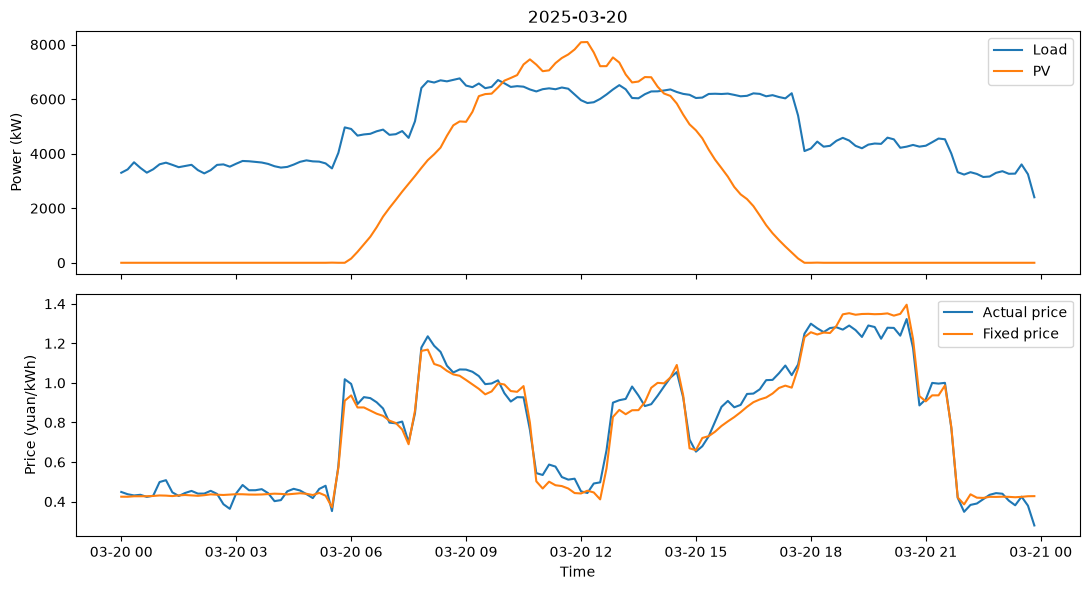

In [8]:
DAY = '2025-03-20'
day_data = actual_10min.loc[actual_10min.date == pd.Timestamp(DAY)].copy()
assert len(day_data) == 144, '日期不在数据范围内'
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(day_data.interval_start, day_data.load_actual_kw, label='Load')
axes[0].plot(day_data.interval_start, day_data.pv_actual_kw, label='PV')
axes[0].set(ylabel='Power (kW)', title=DAY)
axes[0].legend()
axes[1].plot(day_data.interval_start, day_data.actual_price_yuan_per_kwh, label='Actual price')
axes[1].plot(day_data.interval_start, day_data.fixed_price_yuan_per_kwh, label='Fixed price')
axes[1].set(ylabel='Price (yuan/kWh)', xlabel='Time')
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. 取决策时可用历史和预报
默认实际数据到区间结束才可见；预报保留所有可用版本。不要把全年表直接交给预测函数。

In [9]:
def history_at(decision_time):
    t = pd.Timestamp(decision_time)
    return actual_10min.loc[actual_10min.interval_end <= t].copy()

def forecasts_at(decision_time):
    t = pd.Timestamp(decision_time)
    return pv_forecast_hourly.loc[
        (pv_forecast_hourly.issue_time <= t) & (pv_forecast_hourly.target_time > t)
    ].copy()

DECISION_TIME = '2025-02-01 00:00'
history = history_at(DECISION_TIME)
available_forecasts = forecasts_at(DECISION_TIME)
print('可用历史行数：', len(history))
display(available_forecasts.tail())

可用历史行数： 4464


,issue_time,horizon_h,pv_forecast_kw,target_time
2995,2025-02-01,20,0.0,2025-02-01 20:00:00
2996,2025-02-01,21,0.0,2025-02-01 21:00:00
2997,2025-02-01,22,0.0,2025-02-01 22:00:00
2998,2025-02-01,23,0.0,2025-02-01 23:00:00
2999,2025-02-01,24,0.0,2025-02-02 00:00:00


## 8. 导出基础数据
默认不写文件。需要导出时将 EXPORT 改为 True；每次导出到新的时间戳目录，避免覆盖已有结果。

检查范围包括时间完整性、数值有效性和连接行数；不代表已完成异常跳变或预报误差分析。小时到十分钟转换需要确定边界规则后再加。

In [10]:
EXPORT = True
if EXPORT:
    from datetime import datetime
    output = ROOT / '处理结果' / datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    output.mkdir(parents=True, exist_ok=False)
    tables = {'q1_day': q1_day, 'fixed_price': fixed_price,
              'actual_10min': actual_10min, 'pv_forecast_hourly': pv_forecast_hourly}
    for name, table in tables.items():
        table.to_csv(output / f'{name}.csv', index=False, encoding='utf-8-sig', date_format='%Y-%m-%d %H:%M:%S')
    (output / '处理说明.md').write_text(
        '# 处理说明\n来源：附件1—4。原文件未修改；未删除或填补数值。\n'
        '采用区间平均功率假设，十分钟电量=功率/6。此口径需与建模人员确认。\n'
        '全年实际52560行，小时预报35040行；小时预报未做十分钟插值。\n'
        '已检查时间、缺失、非数值、负数、唯一键和合并行数。\n'
        '尚未完成：异常跳变、预报误差分析、调度优化。\n', encoding='utf-8')
    print('已导出：', output)
else:
    print('暂不导出；将 EXPORT 改为 True 后运行本格即可。')

已导出： /Users/mike/Desktop/国赛/处理结果/20260910_105607_986804


## 9. 你的分析区
在下面添加数据筛选、统计或模型。已有变量：`q1_day`、`actual_10min`、`pv_forecast_hourly`。

In [11]:
# 例：按日统计实际用电量和光伏电量
daily_energy = actual_10min.groupby("date")[["load_actual_kwh", "pv_actual_kwh"]].sum()
display(daily_energy.head())

,load_actual_kwh,pv_actual_kwh
date,,
2025-01-01,127286.152383,35250.982367
2025-01-02,127657.078483,34771.839217
2025-01-03,81883.556717,36378.615350
2025-01-04,81891.730067,37126.127700
2025-01-05,127674.118833,36638.408533
